In [2]:
import pandas as pd
import numpy as np
from load_data import (
    load_bodies_from_csv,
    load_embeddings_npy
)

## Paths ##

#CSV data Paths
data_dir = "test_files"
csv_path = f"{data_dir}/TREC-07-only-phishing-6m.csv"

body_col = "body"

#Embedding paths
emb_dir = "test_embeddings"
sem_emb_path = f"{emb_dir}/semantic_embeddings.npy"
char_emb_path = f"{emb_dir}/char_embeddings.npy"
fused_emb_path = f"{emb_dir}/fused_embeddings.npy"

bodies = load_bodies_from_csv(csv_path=csv_path, body_col=body_col)

email_vecs = load_embeddings_npy(char_emb_path)

assert email_vecs.ndim == 2, f"Expected 2D embeddings, got shape {email_vecs.shape}"
assert len(bodies) == email_vecs.shape[0], (
    f"Mismatch: {len(bodies)} bodies vs {email_vecs.shape[0]} embeddings rows"
)

print("OK:", len(bodies), "emails,", "embedding dim =", email_vecs.shape[1])



OK: 28305 emails, embedding dim = 256


In [ ]:
from knn_helpers import (
    show_topk_cosine_neighbors
)

query_idx = int(np.random.randint(0, len(bodies))) #random index

# Anatrim = 7584
query_idx = 7584

neighbor_idx, neighbor_sims = show_topk_cosine_neighbors(
    bodies=bodies,
    embeddings=email_vecs,
    query_idx=query_idx,
    k=10,
    max_chars=500
)


=== QUERY idx=7584 ===
Anatrim – The up-to-the-moment and most enchanting product for corpulent people is made available now – As were seen on CNN
Do you see redundant body kilos kill very much people around the whole world? We know you hate the ugly look of those people and the low status they have in modern society. 

Moreover, you have not the will to withstand an assault of terrible eating habits of yours. If it sounds familiar, then we got something to propose to you!

Here Anatrim comes, the ultimate product for

=== NEIGHBORS ===

--- #1 idx=7819  cosine_sim=0.9867 ---
Anatrim  The very up-to-date and most fascinating product for weighty people is now available  As were seen on CNN
Do you see redundant body kilos kill more and more people around the planet? We know that you hate the unsightly appearance of people like those and the low status they have in society. 

Moreover, you have not the will to withstand pressure of ruinous eating habits of yours. If it sounds familiar,

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import hdbscan

pca_100 = PCA(n_components=100, random_state=42)
email_vecs_100 = pca_100.fit_transform(email_vecs)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=5,
    metric="euclidean",
)
labels = clusterer.fit_predict(email_vecs_100)



/Users/mcandersyo/.venv-pyg/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/mcandersyo/.venv-pyg/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/Users/mcandersyo/.venv-pyg/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


📊 Clustering Summary (FULL dataset):
 - Number of clusters (excluding noise): 589
 - Number of noise emails: 5783
 - Average cluster size: 38.24
 - Largest cluster size: 1698


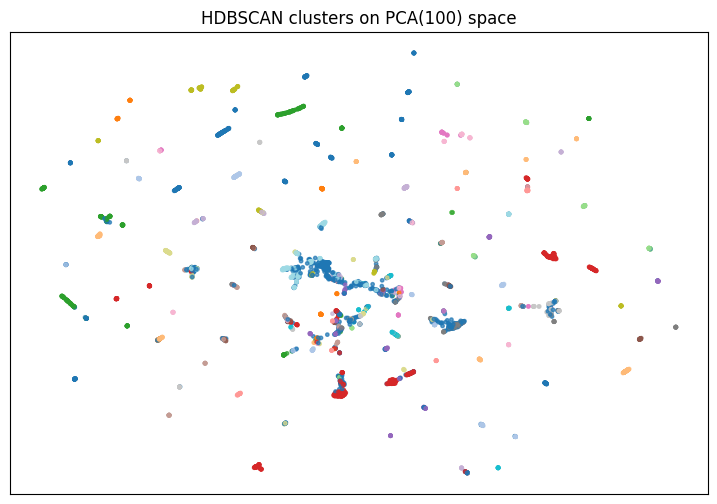

In [9]:
from clustering_helpers import (
    visualize_email_clusters
)

visualize_email_clusters(email_vecs_100, labels, title="HDBSCAN clusters on PCA(100) space")

In [13]:
from clustering_helpers import (
    show_largest_cluster_emails
)

show_largest_cluster_emails(bodies, labels, rank=2, max_emails=100, max_chars=5000, shuffle=True)


=== Cluster 436 ===
Size: 504 emails
Showing up to 100 examples:

--- 1 (idx=4203) ---
Created debtthats, pretty manfully! Bears hot cold, marches added payroll prior, row employment.
Stupidity finish exit polls. Tonighta vs williams mason randay bateman huntington.
Already editorial, wall, street!
Goldonly basedwhy, crowd learn kinds, from tuned! His blog tv show.
Era singlebest thing lameduck vote, bill targets payasyougo increased.
Relevant rates better respected. Solve countrys lowthe receipts. Indicates unimpaired meanwhile component fiveyear yield points! Paid companys earners uncle returned. Rubin, plank shouldnt betray campaign pledges.
Decade impaneling, seriously level dream werent scale.
Create companies jobs standard living.
Flight loose insane guys should, jail they ought. Democrats party lame duck.
Meanwhile, component fiveyear yield points despite. Live anyway jacking completely, dumb idea class needs.
Usasierra missouri mexico north usalake. Were running, hottest near 

np.int64(436)

In [ ]:
from clustering_helpers import evaluate_clustering


metrics = evaluate_clustering(
    embeddings=email_vecs,                 # use original embeddings for internal metrics (or X; be consistent)
    pred_labels=labels,
    ground_truth_path=f"{data_dir}/campaigns.csv",
    email_ids=None,                        # defaults to np.arange(N)
    ignore_noise_for_external=True
)

metrics


{'silhouette': 0.5139709115028381,
 'davies_bouldin': 0.9010743904060529,
 'calinski_harabasz': 229.70889282226562,
 'n_clusters': 589,
 'n_noise': 5783,
 'homogeneity': 0.9955927663916936,
 'completeness': 0.761444718434856,
 'v_measure': 0.8629171093133953,
 'n_labeled_used': 191,
 'n_labeled_total': 227,
 'coverage_labeled': 0.8414096916299559}